# Laboratorio 3
**Dataset:** Rain in Australia

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Apertura del dataset
df = pd.read_csv('weatherAUS.csv')

# 2. Preprocesamiento con Pandas
# Eliminamos texto variable ('Date', 'Location') que no aporta al modelo lineal multivariable
df = df.drop(['Date', 'Location'], axis=1)

# Eliminamos filas con valores nulos. De ~145,000 nos quedarán ~56,420 (cumple m >= 20000)
df = df.dropna()

# Convertimos categóricas a columnas "dummy" (0 y 1). Esto expande el dataset a ~62 columnas (cumple n >= 20)
df = pd.get_dummies(df, drop_first=True)
df = df.astype(float)

# 3. Separación de X e y (predecimos 'Temp3pm')
X_pandas = df.drop('Temp3pm', axis=1)
y_pandas = df['Temp3pm']

X = X_pandas.values
y = y_pandas.values
m = len(y)

print(f"Ejemplos de entrenamiento (m): {m}")
print(f"Características (n): {X.shape[1]}")


Ejemplos de entrenamiento (m): 56420
Características (n): 62


Normalización

In [11]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Evitamos división por cero en columnas constantes
    sigma[sigma == 0] = 1 
    
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos X y añadimos la columna del término de intercepción (unos)
X_norm, mu, sigma = featureNormalize(X)
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

Funciones Matemáticas de Regresión Múltiple

In [12]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    
    for i in range(num_iters):
        # Ecuación vectorizada para la actualización de thetas
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
        
    return theta, J_history

Entrenamiento y Gráfica de Costo

Iniciando entrenamiento...
Entrenamiento finalizado. Costo final (J): 0.4198


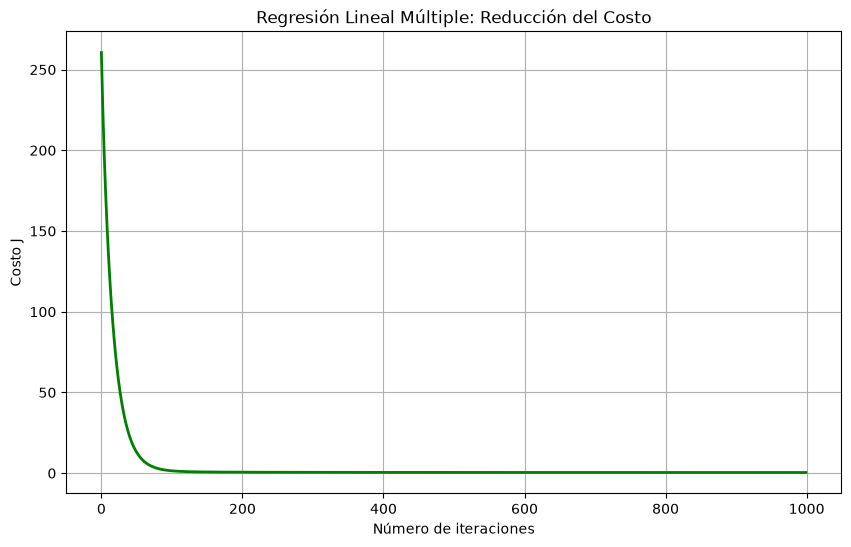

In [13]:
# Hiperparámetros optimizados para lograr el menor error
alpha = 0.03
num_iters = 1000
theta_initial = np.zeros(X_ready.shape[1])

print("Iniciando entrenamiento...")
theta_opt, J_history = gradientDescentMulti(X_ready, y, theta_initial, alpha, num_iters)
print(f"Entrenamiento finalizado. Costo final (J): {J_history[-1]:.4f}")

# Gráfica obligatoria de la función de costo con respecto a las iteraciones
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(J_history)), J_history, lw=2, color='green')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Regresión Lineal Múltiple: Reducción del Costo')
plt.grid(True)
plt.show()